# Lifecycle Portfolio Choice Model

Three-asset lifecycle model with portfolio choice over stocks, nominal bonds, and T-bills. 
Return dynamics follow an annual VAR(1); mortality is earnings-dependent, calibrated to Chetty et al. (2016) and Catherine (2025).

| File | Contents |
|---|---|
| `model.py` | `LifecyclePortfolioModel`, `DiscretizationConfig`, `SolverConfig`; utility, bequest, income, and tax functions |
| `var.py` | VAR estimation, state/return partitioning, annualization |
| `discretization.py` | Rouwenhorst discretization, income grid, Gauss-Hermite quadrature |
| `precompute.py` | `Precompute` class; `build_model` factory |
| `solver.py` | Backward induction solver: EGM + 2D Newton-Raphson |
| `diagnostics.py` | Pre-solve calibration report, Newton failure analysis |
| `simulation.py` | Forward simulation of household lifecycle paths |
| `mortality.py` | Survival probability calibration |

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from model import DiscretizationConfig, SolverConfig
from var import build_nominal_system1_var_config, annualize_var_config
from precompute import build_model, Precompute
from solver import run_lifecycle_solver
from diagnostics import print_model_diagnostic_report, diagnose_terminal_portfolio_states, print_simulation_income_report
from simulation import simulate_lifecycle
from policy_io import save_policy_bundle

### Step 1: Estimate VAR
Estimate quarterly VAR from data, then annualise to annual frequency.
The DP model uses ANNUAL periods (ages 22-99, beta=0.96).

In [19]:
# Resolve dataset path robustly regardless of kernel launch directory.
_path_candidates = [
    Path("var/var_dataset.csv"),
    Path("../var/var_dataset.csv"),
]
_VAR_CSV = next((p for p in _path_candidates if p.exists()), None)
if _VAR_CSV is None:
    raise FileNotFoundError(
        "Could not find var_dataset.csv. Tried: "
        + ", ".join(str(p) for p in _path_candidates)
    )

var_config_q, var_res, var_data = build_nominal_system1_var_config(csv_path=str(_VAR_CSV))
var_config = annualize_var_config(var_config_q, h=4)

VAR ESTIMATION SUMMARY
Estimation mode: restricted
Sample: 1980-03-31 to 2025-12-31
Columns: ['rtb', 'xr', 'xb', 'y_nom', 'dp']
State indices: (0, 3, 4)
Return indices: (1, 2)
VAR k=5, T=183
Max |Phi[:, return_lag_cols]|: 0.000e+00

Intercept vector (const):
[-0.01804   0.308322 -0.032652  0.001431 -0.259384]

Residual correlation matrix:
[[ 1.     -0.0545  0.3102 -0.3295  0.054 ]
 [-0.0545  1.     -0.0919  0.0855 -0.9735]
 [ 0.3102 -0.0919  1.     -0.9973  0.094 ]
 [-0.3295  0.0855 -0.9973  1.     -0.0882]
 [ 0.054  -0.9735  0.094  -0.0882  1.    ]]

Equation R2:
  rtb: 0.4874
  xr: 0.0609
  xb: 0.0214
  y_nom: 0.9645
  dp: 0.9663
annualize_var_config: compounded 4 quarters to 1 annual period.
  Phi_11 diagonal (annual): [0.01694945 0.86113351 0.80693056]
  xr: quarterly mean=1.34%  annual mean=5.36%  ratio=4.0000
  xb: quarterly mean=0.59%  annual mean=2.36%  ratio=4.0000


### Step 2: Parameters

All numerical choices for the model run are set here.

#### Economic calibration

In [20]:
# --- Preferences & bequest ---
gamma = 3.0          # relative risk aversion
beta  = 0.96         # annual discount factor
b_bar = 10           # bequest horizon in years (bond maturity, Catherine 2025)

# --- Lifecycle ages ---
start_age    = 22    # age at labor market entry
retire_age   = 67    # age of retirement
terminal_age = 99    # final model period

# --- Age-earnings profile (Catherine 2025) ---
# log y = b0 + b1*Age + b2*Age^2/10 + b3*Age^3/100
b0, b1, b2, b3 = -6.142, 0.3040, -0.051, 0.002586   # intercept, linear, quadratic/10, cubic/100

# --- Persistent income process (Guvenen et al. 2022) ---
# Two-component mixture: shocks drawn from high- or low-variance component each period.
rho = 0.991          # AR(1) on log permanent income
pz  = 0.176          # weight on high-variance mixture component
mu_eta1    = -0.524;  sigma_eta1 = 0.113   # low-variance component: mean, std dev
mu_eta2    = -(pz / (1.0 - pz)) * mu_eta1  # high-variance component mean (zero-mean condition, derived)
sigma_eta2 = 0.046                          # high-variance component std dev

# --- Transitory income shocks ---
mu_eps1    = 0.134;  sigma_eps1 = 0.762    # mixture component 1: mean, std dev
mu_eps2    = 0.0;    sigma_eps2 = 0.055    # mixture component 2: mean, std dev
pe         = 0.044   # mixing weight on transitory shock component 1

# --- Portfolio constraints ---
constrained = True   # False = allow leverage / short positions

base_config = {
    "beta": beta, "gamma": gamma, "b_bar": b_bar,
    "start_age": start_age, "retire_age": retire_age, "terminal_age": terminal_age,
    "b0": b0, "b1": b1, "b2": b2, "b3": b3,
    "rho": rho, "pz": pz,
    "mu_eta1": mu_eta1, "sigma_eta1": sigma_eta1,
    "mu_eta2": mu_eta2, "sigma_eta2": sigma_eta2,
    "pe": pe,
    "mu_eps1": mu_eps1, "sigma_eps1": sigma_eps1,
    "mu_eps2": mu_eps2, "sigma_eps2": sigma_eps2,
    "constrained": constrained,
}

#### Discretization and solver

Grid sizes control the accuracy of the state-space approximation. 
Solver fields below are the primary tuning knobs; numerical stability constants use class defaults in `model.py`.

In [21]:
disc_config = DiscretizationConfig(
    n_wealth=150,
    n_savings=150,
    state_grid_sizes=(7, 7, 7),    # (rtb, y_nom, dp) -- 343 states
    n_z=11,                        # Rouwenhorst grid points for permanent income
    n_eps_nodes=5,                 # Gauss-Hermite nodes for transitory shock (doubled internally)
    n_ret_nodes_1d=3,              # quadrature order per return dimension; K=1 -> point mass at conditional mean
    consistency_tol_error=0.15,    # relaxed from 0.1; 8-point Rouwenhorst hits ~0.105
)

solver_config = SolverConfig(
    # --- Convergence ---
    tol=1e-7,
    max_iter=20,                   # constrained Newton
    max_iter_unconstrained=5000,   # unconstrained Newton 
    # --- Initial portfolio guess ---
    init_alpha_s=0.1,              # initial stock share
    init_alpha_b=0.4,              # initial bond share
    # --- Step control ---
    step_damp_constrained=0.2,     # max Newton step length (constrained)
    step_damp_unconstrained=0.3,   # max Newton step length (unconstrained)
    # numerical stability constants -> class defaults
)

#### Simulation

In [22]:
# ── Simulation defaults ──────────────────────────────────────────────────────

sim_defaults = dict(
    n_simulations       = 10_000,
    seed                = 42,
    initial_wealth      = 0.1,
    initial_z           = "normal",
    initial_z_normal_std = 0.652,
    initial_state       = "median",
    return_draw_mode    = "monte_carlo",
)

def run_sim(label="baseline", verbose=True, **overrides):
    """Run simulate_lifecycle with defaults, overriding any kwargs. Returns (label, sim_data)."""
    kw = {**sim_defaults, **overrides}
    print(f"\n{'─'*40}\nSimulation: {label}\n{'─'*40}")
    sd = simulate_lifecycle(C_mat, S_mat, B_mat, pc, model, verbose=verbose, **kw)
    sd['label'] = label
    if verbose:
        print_simulation_income_report(model, pc, sd)
    return sd

### Step 3: Build Model and Precompute

Assembles `LifecyclePortfolioModel` from `base_config` and the estimated VAR, 
then precomputes grids, transitions, and income quadrature.

In [23]:
model = build_model(base_config, var_config, verbose=True)
pc    = Precompute(model, disc_config)

VAR PARTITION SUMMARY
Full variables: ['rtb', 'xr', 'xb', 'y_nom', 'dp']
State variables (on grid): ['rtb', 'y_nom', 'dp']
Return variables (integrated): ['xr', 'xb']

Slow-state sub-VAR:
  Phi_11 eigenvalues (|.|): [0.9162, 0.7656, 0.0032]
  Max |eigenvalue| = 0.9162  --  STATIONARY

Restriction check (should be near zero if imposed):
  ||Phi_12|| = 0.000000e+00   (lagged returns -> states)
  ||Phi_22|| = 0.000000e+00   (lagged returns -> returns)

Conditional return variance explained by slow-state conditioning:
  xr:  89.76%  explained  (residual var = 0.001805)
  xb:  98.82%  explained  (residual var = 0.000148)

  EARNINGS-DEPENDENT MORTALITY CALIBRATION
  Catherine (2025) eq. (35), conditioned on persistent income z
  Income params: rho=0.9910  sigma_z=1.8697
  z grid: 11 pts  [-5.6090, 5.6090]
  SSA table: 2017 (2020 TR), gender-averaged
  Targets: Chetty et al. (2016), race-adjusted, gender-averaged

         z  pctile      chi   target   actual  err(yr)
  ──────── ─────── ────

### Step 4: Pre-Solve Diagnostics

In [24]:
# periods_per_year=1 because model uses ANNUAL parameters.
print_model_diagnostic_report(model, pc, periods_per_year=1)

# Terminal-stage portfolio diagnostic before the full lifecycle solve.
terminal_diag = diagnose_terminal_portfolio_states(model, pc)


  1.  PREFERENCES & LIFECYCLE

  --- Utility & bequest ---
  gamma  = 3.000   (CRRA risk aversion)
  beta   = 0.960000  per period   ->   0.960000  annualized
  b_bar  = 10   (bequest horizon in years, Catherine 2025)

  --- Lifecycle ---
  Ages:  22 - 99   (78 periods total)
  Retirement at 67:   45 working periods,  33 retirement periods

  --- Survival probabilities at key ages (earnings-dependent) ---
   Age       low-z       mid-z      high-z
    25     0.99813     0.99909     0.99942
    30     0.99749     0.99878     0.99922
    40     0.99610     0.99810     0.99878
    50     0.99314     0.99666     0.99786
    55     0.98988     0.99507     0.99684
    60     0.98479     0.99260     0.99525
    65     0.97814     0.98936     0.99317
    70     0.96911     0.98497     0.99035
    75     0.95232     0.97679     0.98511
    80     0.92076     0.96143     0.97525

  2.  INCOME PROCESS

  --- Persistent AR(1) with mixture-normal innovations ---
  rho        = 0.99100  (per-period

### Step 5: Solve
First call triggers Numba JIT compilation (~30-60s); subsequent calls are fast.

In [17]:
# -- Constrained solve --
C_mat, S_mat, B_mat, diagnostics = run_lifecycle_solver(model, pc, solver_config=solver_config)

run_config_constrained = {
    "base_config": base_config,
    "discretization_config": disc_config._asdict(),
    "solver_config": solver_config._asdict(),
    "var_config": var_config,
    "constrained": bool(model.constrained),
    "solve_label": "constrained",
}

constrained_bundle = save_policy_bundle(
    Path("saved_runs") / f"constrained_grid{'x'.join(map(str, pc.state_grid_sizes))}_nz{pc.n_z}",
    C_mat,
    S_mat,
    B_mat,
    diagnostics=diagnostics,
    run_config=run_config_constrained,
    overwrite=True,
)
print(f"Saved constrained policy bundle to: {constrained_bundle}")


LIFECYCLE PORTFOLIO SOLVER  (EGM + 2D Newton)
  Mode: CONSTRAINED
  Solver: SolverConfig(tol=1e-07, max_iter=20, max_iter_unconstrained=5000, edge_max_iter=8, init_alpha_s=0.1, init_alpha_b=0.4, step_damp_constrained=0.2, step_damp_unconstrained=0.3, grad_step_size=0.05, tiny_savings=1e-06, corner_tol=1e-08, edge_accept_factor=10.0, singular_det=1e-15, grad_denom_eps=1e-10, min_wealth_inv=1e-10, min_consumption=1e-10, min_return_power=1e-15, prob_skip_threshold=1e-12, euler_inv_floor=1e-20, egm_anchor=1e-10)
  Discretization: DiscretizationConfig(n_wealth=150, wealth_min=0.0001, wealth_max=200.0, n_savings=150, savings_min=1e-08, state_grid_sizes=(7, 7, 7), n_z=11, n_eps_nodes=5, n_ret_nodes_1d=3, consistency_tol_warn=0.02, consistency_tol_error=0.15)
  Ages 22–99  (78 periods)
  Grids: n_w=150, n_s=150, n_z=11, N_state=343
  gamma=3.0, beta=0.96, b_bar=10
  States per period: 11 × 343 = 3,773

  Terminal condition (age 99) ... done  [c range: 0.000–25.327]  [portfolio: 7 interior, 33

In [ ]:
# -- Unconstrained solve (separate run, reuses same Precompute) --
model_unc = model._replace(constrained=False)
solver_config_unc = SolverConfig(
    **{**solver_config._asdict(),
       'init_alpha_s': 0.40,
       'init_alpha_b': 0.33,
       'max_iter_unconstrained': 8000,
    }
)
C_mat_unc, S_mat_unc, B_mat_unc, diagnostics_unc = run_lifecycle_solver(model_unc, pc, solver_config=solver_config_unc)

run_config_unconstrained = {
    "base_config": {**base_config, "constrained": False},
    "discretization_config": disc_config._asdict(),
    "solver_config": solver_config_unc._asdict(),
    "var_config": var_config,
    "constrained": bool(model_unc.constrained),
    "solve_label": "unconstrained",
}

unconstrained_bundle = save_policy_bundle(
    Path("saved_runs") / f"unconstrained_grid{'x'.join(map(str, pc.state_grid_sizes))}_nz{pc.n_z}",
    C_mat_unc,
    S_mat_unc,
    B_mat_unc,
    diagnostics=diagnostics_unc,
    run_config=run_config_unconstrained,
    overwrite=True,
)
print(f"Saved unconstrained policy bundle to: {unconstrained_bundle}")


LIFECYCLE PORTFOLIO SOLVER  (EGM + 2D Newton)
  Mode: UNCONSTRAINED
  Solver: SolverConfig(tol=1e-07, max_iter=20, max_iter_unconstrained=8000, edge_max_iter=8, init_alpha_s=0.4, init_alpha_b=0.33, step_damp_constrained=0.2, step_damp_unconstrained=0.3, grad_step_size=0.05, tiny_savings=1e-06, corner_tol=1e-08, edge_accept_factor=10.0, singular_det=1e-15, grad_denom_eps=1e-10, min_wealth_inv=1e-10, min_consumption=1e-10, min_return_power=1e-15, prob_skip_threshold=1e-12, euler_inv_floor=1e-20, egm_anchor=1e-10)
  Discretization: DiscretizationConfig(n_wealth=150, wealth_min=0.0001, wealth_max=200.0, n_savings=150, savings_min=1e-08, state_grid_sizes=(7, 7, 7), n_z=11, n_eps_nodes=5, n_ret_nodes_1d=3, consistency_tol_warn=0.02, consistency_tol_error=0.15)
  Ages 22–99  (78 periods)
  Grids: n_w=150, n_s=150, n_z=11, N_state=343
  gamma=3.0, beta=0.96, b_bar=10
  States per period: 11 × 343 = 3,773

  Terminal condition (age 99) ... done  [c range: 0.000–169.869]  [portfolio: 343 interi

In [11]:
# Re-run the reusable terminal diagnostic if you want to inspect failures again
# after changing the discretization, leverage regime, or solver settings.
terminal_diag = diagnose_terminal_portfolio_states(model, pc)


TERMINAL PORTFOLIO DIAGNOSTIC
Mode: CONSTRAINED
States: 125  interior=5  corner/edge=120  fail=0
Solver residuals: min=0.000e+00  median=0.000e+00  max=1.551e-05
No terminal failures detected.


### Step 6: Simulate Households
Run a first lifecycle simulation using the solved policy functions.

In [30]:
sim_data = run_sim("baseline")


────────────────────────────────────────
Simulation: baseline
────────────────────────────────────────
SIMULATING LIFECYCLE PATHS
  Households:          10,000
  Ages:                22 to 99 (78 periods)
  Retirement age:      67 (index 45)
  Income x fin state:  5 z x 125 s = 625 combined states
  Return quad nodes:   9 (K=3 per dim)
  Return draw mode:    monte_carlo
  sigma_resid (xr,xb): 0.0425, 0.0121

  Initial wealth: 0.100 before income
  Initial x = wealth + Y0  |  mean=0.292  p25=0.254  p75=0.266
  Initial z state:     normal
  Initial z sigma:     0.652
  Initial fin state:   median

  Running simulation...

  Simulation complete: 0.06s
  Survival to age 99: 5.4%
  Median death age: 85

  Cash-on-hand by phase
  Phase                age  alive%      p25      p50      p75
  Start                 22  100.0%    0.254    0.254    0.266
  Mid-work              44  96.9%    1.930    2.199    2.585
  Pre-retire            66  86.3%    3.485    4.275    5.390
  Retire             

### Step 7: Results & Plotting
Add your analysis and plotting code here.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ── Shared helper ────────────────────────────────────────────────────────────

def cross_sectional_stats(data, alive):
    """Compute cross-sectional mean and percentiles at each age, conditional on survival."""
    n_ages = data.shape[1]
    out = {k: np.zeros(n_ages) for k in
           ['mean', 'std', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'n_alive']}
    for t in range(n_ages):
        mask = alive[:, t]
        n = np.sum(mask)
        out['n_alive'][t] = n
        if n > 0:
            d = data[mask, t]
            out['mean'][t] = np.mean(d)
            out['std'][t]  = np.std(d)
            for tag, q in [('p5',5),('p10',10),('p25',25),('p50',50),
                           ('p75',75),('p90',90),('p95',95)]:
                out[tag][t] = np.percentile(d, q)
    return out

# ── Colour palette ───────────────────────────────────────────────────────────

COLORS = {
    'consumption': '#2ecc71',
    'income':      '#3498db',
    'wealth':      '#9b59b6',
    'stocks':      '#e74c3c',
    'bonds':       '#1abc9c',
    'bills':       '#f39c12',
}

## Phase 1 Results

Implements the Phase 1 figures and tables from `RESULTS.md`. All cells below
read from `model`, `pc`, `C_mat`/`S_mat`/`B_mat`, `diagnostics`, and
`sim_data` (the baseline simulation produced by `run_sim("baseline")`).


In [ ]:
# Phase 1 setup: shared indices, helpers, stationary distribution

n_w     = pc.n_w
n_z     = pc.n_z
N_state = pc.N_state
n_age   = pc.n_age
ages    = pc.ages
mid_z   = n_z // 2
mid_s   = N_state // 2
retire_t = model.retire_age - model.start_age


def get_i_w_rep(sim, t):
    """Index into pc.wealth_grid closest to median simulated wealth at age t."""
    alive_t = sim["alive"][:, t]
    if not np.any(alive_t):
        return n_w // 2
    med_w = np.median(sim["x"][alive_t, t])
    return int(np.argmin(np.abs(pc.wealth_grid - med_w)))


i_w_rep_per_age = np.array([get_i_w_rep(sim_data, t) for t in range(n_age)])
i_w_rep_fixed   = get_i_w_rep(sim_data, 45 - model.start_age)

# Income quintile bins, derived dynamically from n_z so this works for any grid size.
def _build_quintile_bins(n_z):
    edges = np.linspace(0, n_z, 6).astype(int)  # 6 boundaries -> 5 bins
    labels = ["Q1 (low)", "Q2", "Q3 (mid)", "Q4", "Q5 (high)"]
    bins = {}
    for q in range(5):
        idxs = list(range(edges[q], edges[q + 1]))
        if not idxs:
            idxs = [min(edges[q], n_z - 1)]
        bins[labels[q]] = idxs
    return bins

quintile_bins = _build_quintile_bins(n_z)


def get_state_slice(vary_dim):
    """Joint state indices where every dim != vary_dim is at its median."""
    sizes = pc.state_grid_sizes
    mid_idx = [n // 2 for n in sizes]
    out = []
    for i_s in range(N_state):
        idx = pc.state_indices[i_s]
        if all(idx[d] == mid_idx[d] for d in range(len(sizes)) if d != vary_dim):
            out.append(i_s)
    return out


def stationary_dist(P, tol=1e-12, max_iter=20000):
    n = P.shape[0]
    pi = np.full(n, 1.0 / n)
    for _ in range(max_iter):
        nxt = pi @ P
        if np.max(np.abs(nxt - pi)) < tol:
            return nxt
        pi = nxt
    return pi


pi_state_stationary = stationary_dist(pc.Pi_state)

print(f"Setup ready: n_age={n_age}, n_z={n_z}, N_state={N_state}, "
      f"mid_z={mid_z}, mid_s={mid_s}, retire_t={retire_t}")
print(f"i_w_rep_fixed (age 45) = {i_w_rep_fixed}  "
      f"(wealth = {pc.wealth_grid[i_w_rep_fixed]:.3f})")
print(f"quintile_bins = {quintile_bins}")


### Table 1 — Calibration parameters


In [ ]:
# TABLE 1 — Calibration parameters
print("=" * 64)
print("  TABLE 1 — CALIBRATION PARAMETERS")
print("=" * 64)

print("\nA. Preferences and lifecycle")
print(f"  gamma (risk aversion)     = {model.gamma}")
print(f"  beta  (discount factor)   = {model.beta}")
print(f"  b_bar (bequest horizon)   = {model.b_bar}")
print(f"  start_age                 = {model.start_age}")
print(f"  retire_age                = {model.retire_age}")
print(f"  terminal_age              = {model.terminal_age}")
print(f"  constrained               = {model.constrained}")

print("\nB. Income process (Guvenen et al. 2022)")
print(f"  age polynomial b0..b3      = "
      f"{model.b0:.4f}, {model.b1:.4f}, {model.b2:.4f}, {model.b3:.4f}")
print(f"  rho  (persistence)         = {model.rho}")
print(f"  pz                         = {model.pz}")
print(f"  mu_eta1, sigma_eta1        = {model.mu_eta1:.4f}, {model.sigma_eta1:.4f}")
print(f"  mu_eta2, sigma_eta2        = {model.mu_eta2:.4f}, {model.sigma_eta2:.4f}")
print(f"  pe                         = {model.pe}")
print(f"  mu_eps1, sigma_eps1        = {model.mu_eps1:.4f}, {model.sigma_eps1:.4f}")
print(f"  mu_eps2, sigma_eps2        = {model.mu_eps2:.4f}, {model.sigma_eps2:.4f}")

print("\nC. VAR (annual, partitioned)")
print(f"  state variables  : {model.state_names}")
print(f"  return variables : {model.ret_names}")
print(f"  z_bar_state      = {np.round(model.z_bar_state, 4)}")
print(f"  z_bar_ret        = {np.round(model.z_bar_ret, 4)}")
print(f"  diag(Phi_11)     = {np.round(np.diag(model.Phi_11), 4)}")
print(f"  M (return loadings on state):")
print(np.round(model.M, 4))


### Table 4 — Solver diagnostics


In [ ]:
# TABLE 4 — Solver diagnostics
d  = diagnostics
ai = d["age_diag_int"]
af = d["age_diag_fsum"]

# Constants from solver.py
DI_CORNER_BILLS=0; DI_CORNER_STOCKS=1; DI_CORNER_BONDS=2
DI_EDGE_SB=3;      DI_EDGE_BB=4;       DI_EDGE_STOCKBOND=5
DI_INTERIOR=6;     DI_NEWTON_FAIL=7;   DI_TINY_SAVINGS=9
DF_SUM_FOC_RESID_SQ=2

total_calls = d["total_calls"]
fails       = d["total_newton_failures"]
worst_foc   = d["worst_foc_resid"]
ss_foc      = af[:, DF_SUM_FOC_RESID_SQ].sum()
rms_foc     = float(np.sqrt(ss_foc / max(total_calls, 1)))

interior = ai[:, DI_INTERIOR].sum()
edges    = ai[:, [DI_EDGE_SB, DI_EDGE_BB, DI_EDGE_STOCKBOND]].sum()
corners  = ai[:, [DI_CORNER_BILLS, DI_CORNER_STOCKS, DI_CORNER_BONDS]].sum()
tiny     = ai[:, DI_TINY_SAVINGS].sum()

def pct(x): return 100.0 * x / max(total_calls, 1)

print("=" * 56)
print("  TABLE 4 — SOLVER DIAGNOSTICS")
print("=" * 56)
print(f"  Total Newton calls          : {total_calls:>14,}")
print(f"  Newton failure rate         : {pct(fails):>14.4f}%")
print(f"  Worst FOC residual          : {worst_foc:>14.2e}")
print(f"  RMS  FOC residual           : {rms_foc:>14.2e}")
print(f"  Interior solutions          : {pct(interior):>14.2f}%")
print(f"  Edge solutions              : {pct(edges):>14.2f}%")
print(f"  Corner solutions            : {pct(corners):>14.2f}%")
print(f"  Tiny-savings (trivial)      : {pct(tiny):>14.2f}%")
print(f"  Failed                      : {pct(fails):>14.2f}%")
print(f"  Total accounted for         : "
      f"{pct(interior + edges + corners + tiny + fails):>14.2f}%")
print(f"  EGM monotonicity violations : {d['total_mono_violations']:>14,}")
print(f"  Constrained solve           : {d['constrained']}")


### Figure 12 — Income and pension profiles


In [ ]:
# FIGURE 12 — Income and pension profiles
fig, ax = plt.subplots(figsize=(9, 5))
work_t = np.where(ages <  model.retire_age)[0]
ret_t  = np.where(ages >= model.retire_age)[0]

for label, z_idx, color in [("low (Q1)", 1,         "#3498db"),
                             ("median",  mid_z,     "#2ecc71"),
                             ("high (Q5)", n_z - 2, "#e74c3c")]:
    profile = np.zeros(n_age)
    for t in work_t:
        profile[t] = float(np.dot(pc.eps_weights, pc.working_income[t, z_idx, :]))
    for t in ret_t:
        profile[t] = pc.pension_after_tax[t, z_idx]
    ax.plot(ages, profile, label=f"z = {label}", color=color, lw=2)

ax.axvline(model.retire_age, ls="--", color="k", alpha=0.5, label="Retirement")
ax.set_xlabel("Age"); ax.set_ylabel("After-tax income (model units)")
ax.set_title("Figure 12 — Income and pension profiles")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Figure 11 — Earnings-dependent survival


In [ ]:
# FIGURE 11 — Earnings-dependent survival from age 40
fig, ax = plt.subplots(figsize=(9, 5))
age_40_t  = 40 - model.start_age
ages_plot = ages[age_40_t:]

z_reps = [0, n_z // 4, mid_z, 3 * n_z // 4, n_z - 1]
labels = ["Q1 (lowest)", "Q2", "Q3 (median)", "Q4", "Q5 (highest)"]

for z_idx, lbl in zip(z_reps, labels):
    cum = np.ones(len(ages_plot))
    for k in range(1, len(ages_plot)):
        cum[k] = cum[k - 1] * pc.survival_probs_2d[age_40_t + k - 1, z_idx]
    ax.plot(ages_plot, cum, label=lbl, lw=2)

ax.set_xlabel("Age"); ax.set_ylabel("Cumulative survival from age 40")
ax.set_title("Figure 11 — Earnings-dependent survival (Chetty et al. 2016)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Figure 1 — Policy: portfolio shares vs age


In [ ]:
# FIGURE 1 — Policy: portfolio shares vs age (median state, median wealth)
a_s = np.zeros(n_age); a_b = np.zeros(n_age)
for t in range(n_age):
    iw = i_w_rep_per_age[t]
    a_s[t] = S_mat[t, mid_z, mid_s, iw]
    a_b[t] = B_mat[t, mid_z, mid_s, iw]
a_bill = 1.0 - a_s - a_b

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(ages, a_bill, a_b, a_s,
             labels=["Bills", "Bonds", "Stocks"],
             colors=[COLORS["bills"], COLORS["bonds"], COLORS["stocks"]],
             alpha=0.85)
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.6)
ax.set_xlabel("Age"); ax.set_ylabel("Portfolio share")
ax.set_ylim(0, 1)
ax.set_title("Figure 1 — Policy: portfolio shares vs age (z=mid, state=mid)")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


### Figure 2 — Policy: portfolio shares vs wealth


In [ ]:
# FIGURE 2 — Policy: portfolio shares vs wealth at ages 35, 55, 75
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, age in zip(axes, [35, 55, 75]):
    t = age - model.start_age
    a_s = S_mat[t, mid_z, mid_s, :]
    a_b = B_mat[t, mid_z, mid_s, :]
    a_bill = 1.0 - a_s - a_b
    ax.plot(pc.wealth_grid, a_s,    lw=2, color=COLORS["stocks"], label="Stocks")
    ax.plot(pc.wealth_grid, a_b,    lw=2, color=COLORS["bonds"],  label="Bonds")
    ax.plot(pc.wealth_grid, a_bill, lw=2, color=COLORS["bills"],  label="Bills")
    ax.set_xscale("log"); ax.set_xlabel("Cash-on-hand (log)")
    ax.set_title(f"Age {age}"); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05)
axes[0].set_ylabel("Portfolio share"); axes[0].legend()
plt.suptitle("Figure 2 — Policy: portfolio shares vs wealth")
plt.tight_layout(); plt.show()


### Figure 3 — Policy: portfolio shares vs financial state


In [ ]:
# FIGURE 3 — Policy vs each financial state variable (others at median)
t = 45 - model.start_age
state_var_labels = list(model.state_names) if model.state_names else ["rtb", "y_nom", "dp"]
# Rate-like state vars are stored quarterly in pc.state_grid; multiply by 4 for display.
rate_dims = {model.bill_rate_index_in_state, model.annuity_yield_index_in_state}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, vary_dim, name in zip(axes, [0, 1, 2], state_var_labels):
    slc   = get_state_slice(vary_dim)
    scale = 4.0 if vary_dim in rate_dims else 1.0
    xs    = np.array([pc.state_grid[i_s, vary_dim] * scale for i_s in slc])
    a_sv  = np.array([S_mat[t, mid_z, i_s, i_w_rep_fixed] for i_s in slc])
    a_bv  = np.array([B_mat[t, mid_z, i_s, i_w_rep_fixed] for i_s in slc])
    order = np.argsort(xs)
    ax.plot(xs[order], a_sv[order], "o-", color=COLORS["stocks"], label="Stocks")
    ax.plot(xs[order], a_bv[order], "s-", color=COLORS["bonds"],  label="Bonds")
    unit = " (annualized)" if vary_dim in rate_dims else ""
    ax.set_xlabel(name + unit); ax.set_title(f"vs {name}")
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("Share")
plt.suptitle(f"Figure 3 — Policy vs financial state (age {model.start_age + t}, z=mid)")
plt.tight_layout(); plt.show()


### Figure 4 — Simulated lifecycle profiles


In [ ]:
# FIGURE 4 — Simulated lifecycle profiles (2x2)
alive = sim_data["alive"]
x_st  = cross_sectional_stats(sim_data["x"],       alive)
c_st  = cross_sectional_stats(sim_data["c"],       alive)
y_st  = cross_sectional_stats(sim_data["income"],  alive)
as_st = cross_sectional_stats(sim_data["alpha_s"], alive)
ab_st = cross_sectional_stats(sim_data["alpha_b"], alive)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.fill_between(ages, x_st["p25"], x_st["p75"], alpha=0.3, color=COLORS["wealth"])
ax.plot(ages, x_st["p50"], color=COLORS["wealth"], lw=2, label="Median")
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.5)
ax.set_title("Wealth"); ax.set_xlabel("Age"); ax.grid(alpha=0.3); ax.legend()

ax = axes[0, 1]
ax.fill_between(ages, c_st["p25"], c_st["p75"], alpha=0.3, color=COLORS["consumption"])
ax.plot(ages, c_st["p50"], color=COLORS["consumption"], lw=2, label="Median")
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.5)
ax.set_title("Consumption"); ax.set_xlabel("Age"); ax.grid(alpha=0.3); ax.legend()

ax = axes[1, 0]
ax.plot(ages, y_st["p50"], color=COLORS["income"], lw=2, label="Median income")
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.5)
ax.set_title("Income (labour + pension)"); ax.set_xlabel("Age"); ax.grid(alpha=0.3); ax.legend()

ax = axes[1, 1]
abill_mean = 1.0 - as_st["mean"] - ab_st["mean"]
ax.stackplot(ages, abill_mean, ab_st["mean"], as_st["mean"],
             labels=["Bills", "Bonds", "Stocks"],
             colors=[COLORS["bills"], COLORS["bonds"], COLORS["stocks"]],
             alpha=0.85)
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.6)
ax.set_ylim(0, 1); ax.set_title("Portfolio shares (mean)")
ax.set_xlabel("Age"); ax.legend(loc="upper right")

plt.suptitle("Figure 4 — Simulated lifecycle profiles")
plt.tight_layout(); plt.show()


### Figure 5 — Portfolio by income quintile


In [ ]:
# FIGURE 5 — Portfolio by income quintile at ages 45, 65, 80
def quintile_assign(z_vals):
    out = np.full(z_vals.shape, -1, dtype=int)
    for q, (_, idxs) in enumerate(quintile_bins.items()):
        out[np.isin(z_vals, idxs)] = q
    return out

target_ages_5 = [45, 65, 80]
fig, axes = plt.subplots(1, len(target_ages_5),
                          figsize=(5 * len(target_ages_5), 4.5), sharey=True)

for ax, age in zip(axes, target_ages_5):
    t = age - model.start_age
    am = sim_data["alive"][:, t]
    z_vals = sim_data["z_idx"][am, t]
    q_assign = quintile_assign(z_vals)
    a_s = sim_data["alpha_s"][am, t]
    a_b = sim_data["alpha_b"][am, t]

    n_q = len(quintile_bins)
    bs = np.zeros(n_q); bb = np.zeros(n_q); bbill = np.zeros(n_q)
    for q in range(n_q):
        m = q_assign == q
        if m.any():
            bs[q]    = a_s[m].mean()
            bb[q]    = a_b[m].mean()
            bbill[q] = 1.0 - bs[q] - bb[q]

    xq = np.arange(n_q)
    ax.bar(xq, bbill,                label="Bills",  color=COLORS["bills"])
    ax.bar(xq, bb, bottom=bbill,     label="Bonds",  color=COLORS["bonds"])
    ax.bar(xq, bs, bottom=bbill + bb, label="Stocks", color=COLORS["stocks"])
    ax.set_xticks(xq); ax.set_xticklabels(list(quintile_bins.keys()), rotation=30)
    ax.set_title(f"Age {age}"); ax.set_ylim(0, 1)

axes[0].set_ylabel("Portfolio share"); axes[0].legend(loc="upper right")
plt.suptitle("Figure 5 — Portfolio by income quintile")
plt.tight_layout(); plt.show()


### Figure 6 — Portfolio by financial regime


In [ ]:
# FIGURE 6 — Portfolio by financial regime (y_nom and dp terciles) at age 45
t = 45 - model.start_age
am = sim_data["alive"][:, t]
state_vals = sim_data["state_idx"][am, t]
a_s_alive  = sim_data["alpha_s"][am, t]
a_b_alive  = sim_data["alpha_b"][am, t]

# Identify which column of pc.state_grid is y_nom; dp is the remaining non-rate column.
y_nom_col = model.annuity_yield_index_in_state
bill_col  = model.bill_rate_index_in_state
dp_col    = next(c for c in range(model.n_state) if c not in (y_nom_col, bill_col))

def tercile_split(vals):
    b = np.percentile(vals, [33.333, 66.667])
    return vals <= b[0], (vals > b[0]) & (vals <= b[1]), vals > b[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, col, name in zip(axes, [y_nom_col, dp_col], ["y_nom", "dp"]):
    vals  = pc.state_grid[state_vals, col]
    masks = tercile_split(vals)
    bs = np.zeros(3); bb = np.zeros(3); bbill = np.zeros(3)
    for k, m in enumerate(masks):
        if m.any():
            bs[k]    = a_s_alive[m].mean()
            bb[k]    = a_b_alive[m].mean()
            bbill[k] = 1.0 - bs[k] - bb[k]
    xq = np.arange(3)
    ax.bar(xq, bbill,                 label="Bills",  color=COLORS["bills"])
    ax.bar(xq, bb,    bottom=bbill,   label="Bonds",  color=COLORS["bonds"])
    ax.bar(xq, bs,    bottom=bbill+bb, label="Stocks", color=COLORS["stocks"])
    ax.set_xticks(xq); ax.set_xticklabels(["Low", "Mid", "High"])
    ax.set_title(f"{name} terciles"); ax.set_ylim(0, 1)
axes[0].set_ylabel("Portfolio share"); axes[0].legend(loc="upper right")
plt.suptitle("Figure 6 — Portfolio by financial regime (age 45)")
plt.tight_layout(); plt.show()


### Table 2 — Simulation summary statistics


In [ ]:
# TABLE 2 — Simulation summary statistics
print("=" * 95)
print("  TABLE 2 — SIMULATION SUMMARY STATISTICS")
print("=" * 95)
hdr = (f"  {'Age':>4} {'Surv%':>7} {'medW':>9} {'medC':>9} {'medY':>9} "
       f"{'savRt':>8} {'a_s':>7} {'a_b':>7} {'a_bill':>7}")
print(hdr); print("  " + "-" * (len(hdr) - 2))
for age in [25, 35, 45, 55, 65, 75, 85, 95]:
    t  = age - model.start_age
    am = sim_data["alive"][:, t]
    surv = am.mean() * 100
    if not am.any():
        print(f"  {age:>4}  (no survivors)"); continue
    x = sim_data["x"][am, t]; c = sim_data["c"][am, t]
    y = sim_data["income"][am, t]; s = sim_data["savings"][am, t]
    sr  = float(np.median(s / np.maximum(x, 1e-12)))
    a_s = float(sim_data["alpha_s"][am, t].mean())
    a_b = float(sim_data["alpha_b"][am, t].mean())
    print(f"  {age:>4} {surv:>7.2f} {np.median(x):>9.3f} {np.median(c):>9.3f} "
          f"{np.median(y):>9.3f} {sr:>8.3f} {a_s:>7.3f} {a_b:>7.3f} {1-a_s-a_b:>7.3f}")


### Figure 10 — Consumption-to-wealth ratio


In [ ]:
# FIGURE 10 — Consumption-to-wealth ratio over the lifecycle
cw_med = np.zeros(n_age); cw_p25 = np.zeros(n_age); cw_p75 = np.zeros(n_age)
for t in range(n_age):
    am = sim_data["alive"][:, t]
    if not am.any(): continue
    r = sim_data["c"][am, t] / np.maximum(sim_data["x"][am, t], 1e-12)
    r = r[np.isfinite(r)]
    cw_med[t] = np.median(r)
    cw_p25[t] = np.percentile(r, 25)
    cw_p75[t] = np.percentile(r, 75)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(ages, cw_p25, cw_p75, alpha=0.3, color=COLORS["consumption"])
ax.plot(ages, cw_med, lw=2, color=COLORS["consumption"], label="Median")
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.5)
ax.set_xlabel("Age"); ax.set_ylabel("c / W")
ax.set_title("Figure 10 — Consumption-to-wealth ratio")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()


### Figure 7 — Hedging demand spread


In [ ]:
# FIGURE 7 — Policy variation across financial states (proxy for hedging demand)
as_mean = np.zeros(n_age); as_std = np.zeros(n_age)
ab_mean = np.zeros(n_age); ab_std = np.zeros(n_age)
pi = pi_state_stationary
for t in range(n_age):
    iw   = i_w_rep_per_age[t]
    s_by = S_mat[t, mid_z, :, iw]
    b_by = B_mat[t, mid_z, :, iw]
    as_mean[t] = float(pi @ s_by)
    ab_mean[t] = float(pi @ b_by)
    as_std[t]  = float(np.sqrt(pi @ (s_by - as_mean[t])**2))
    ab_std[t]  = float(np.sqrt(pi @ (b_by - ab_mean[t])**2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, mean, std, name, color in [
    (axes[0], as_mean, as_std, "Stocks", COLORS["stocks"]),
    (axes[1], ab_mean, ab_std, "Bonds",  COLORS["bonds"]),
]:
    ax.fill_between(ages, mean - std, mean + std, alpha=0.3, color=color)
    ax.plot(ages, mean, lw=2, color=color, label="Stationary mean ± 1σ")
    ax.axvline(model.retire_age, ls="--", color="k", alpha=0.5)
    ax.set_xlabel("Age"); ax.grid(alpha=0.3); ax.legend()
    ax.set_title(name)
axes[0].set_ylabel("Share")
plt.suptitle("Figure 7 — Hedging demand spread (variation across financial states)")
plt.tight_layout(); plt.show()


### Figure 13 — Portfolio allocation fan chart


In [ ]:
# FIGURE 13 — Portfolio fan chart (cross-section over agents)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, st, name, color in [
    (axes[0], as_st, "Stocks", COLORS["stocks"]),
    (axes[1], ab_st, "Bonds",  COLORS["bonds"]),
]:
    ax.fill_between(ages, st["p10"], st["p90"], alpha=0.18, color=color, label="p10–p90")
    ax.fill_between(ages, st["p25"], st["p75"], alpha=0.35, color=color, label="p25–p75")
    ax.plot(ages, st["mean"], lw=2, color=color, label="Mean")
    ax.plot(ages, st["p50"], "--", lw=1.5, color="k", label="Median")
    ax.axvline(model.retire_age, ls="--", color="k", alpha=0.4)
    ax.set_xlabel("Age"); ax.set_title(name); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("Share")
plt.suptitle("Figure 13 — Portfolio allocation fan chart")
plt.tight_layout(); plt.show()


### Figure 14 — Wealth composition over the lifecycle


In [ ]:
# FIGURE 14 — Human capital + SS PV + financial wealth
# pc.r_bill_grid is in quarterly decimal units; ×4 to get an approx annual rate.
r_disc = float(pc.r_bill_grid.mean()) * 4.0
hc    = np.zeros(n_age)
ss_pv = np.zeros(n_age)
fin_w = np.zeros(n_age)
z_idx = mid_z

for t in range(n_age):
    am = sim_data["alive"][:, t]
    if am.any():
        fin_w[t] = float(np.median(sim_data["x"][am, t]))
    if ages[t] < model.retire_age:
        for s in range(t, retire_t):
            e_inc = float(np.dot(pc.eps_weights, pc.working_income[s, z_idx, :]))
            cum   = float(np.prod(pc.survival_probs_2d[t:s, z_idx])) if s > t else 1.0
            disc  = (1.0 + r_disc) ** (-(s - t))
            hc[t] += cum * disc * e_inc
    pension = float(pc.pension_after_tax[retire_t, z_idx])
    for s in range(max(t, retire_t), n_age):
        cum  = float(np.prod(pc.survival_probs_2d[t:s, z_idx])) if s > t else 1.0
        disc = (1.0 + r_disc) ** (-(s - t))
        ss_pv[t] += cum * disc * pension

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.stackplot(ages, hc, ss_pv, fin_w,
             labels=["Human capital", "Social Security PV", "Financial wealth"],
             colors=["#e67e22", "#f1c40f", "#3498db"], alpha=0.85)
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.6)
ax.set_xlabel("Age"); ax.set_ylabel("Model units")
ax.set_title("Figure 14 — Wealth composition over the lifecycle (z = median)")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


### Figure 15 — Wealth distribution at key ages


In [ ]:
# FIGURE 15 — Wealth histograms at ages 30, 45, 60, 75
target_ages_15 = [30, 45, 60, 75]
fig, axes = plt.subplots(1, len(target_ages_15), figsize=(4 * len(target_ages_15), 4))
for ax, age in zip(axes, target_ages_15):
    t  = age - model.start_age
    am = sim_data["alive"][:, t]
    w  = sim_data["x"][am, t]
    ax.hist(w, bins=50, density=True, color=COLORS["wealth"], alpha=0.7)
    ax.axvline(np.mean(w),   color="k", lw=1.2,           label=f"mean={np.mean(w):.2f}")
    ax.axvline(np.median(w), color="k", lw=1.2, ls="--",  label=f"med={np.median(w):.2f}")
    ax.set_title(f"Age {age}"); ax.set_xlabel("Cash-on-hand"); ax.legend(fontsize=8)
plt.suptitle("Figure 15 — Wealth distribution at key ages")
plt.tight_layout(); plt.show()


### Figure 16 — Cross-sectional dispersion


In [ ]:
# FIGURE 16 — Cross-sectional dispersion of wealth and consumption
sigma_w = np.zeros(n_age); sigma_c = np.zeros(n_age)
cv_w    = np.zeros(n_age); cv_c    = np.zeros(n_age)
for t in range(n_age):
    am = sim_data["alive"][:, t]
    if not am.any(): continue
    w = sim_data["x"][am, t]; c = sim_data["c"][am, t]
    sigma_w[t] = w.std(); sigma_c[t] = c.std()
    cv_w[t] = sigma_w[t] / max(w.mean(), 1e-12)
    cv_c[t] = sigma_c[t] / max(c.mean(), 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(ages, sigma_w, lw=2, color=COLORS["wealth"],      label="σ wealth")
ax.plot(ages, sigma_c, lw=2, color=COLORS["consumption"], label="σ consumption")
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.4)
ax.set_xlabel("Age"); ax.set_ylabel("Std dev (levels)")
ax.set_title("Levels"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ages, cv_w, lw=2, color=COLORS["wealth"],      label="CV wealth")
ax.plot(ages, cv_c, lw=2, color=COLORS["consumption"], label="CV consumption")
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.4)
ax.set_xlabel("Age"); ax.set_ylabel("Coefficient of variation")
ax.set_title("Normalised"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Figure 16 — Cross-sectional dispersion")
plt.tight_layout(); plt.show()


### Figure 17 — Savings rate over the lifecycle


In [ ]:
# FIGURE 17 — Savings rate over the lifecycle
sav_mean = np.zeros(n_age); sav_std = np.zeros(n_age); sav_med = np.zeros(n_age)
for t in range(n_age):
    am = sim_data["alive"][:, t]
    if not am.any(): continue
    x = sim_data["x"][am, t]; s = sim_data["savings"][am, t]
    r = s / np.maximum(x, 1e-12)
    r = r[np.isfinite(r)]
    sav_mean[t] = r.mean(); sav_std[t] = r.std(); sav_med[t] = np.median(r)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(ages, sav_mean - sav_std, sav_mean + sav_std,
                alpha=0.25, color="#16a085")
ax.plot(ages, sav_mean, lw=2,  color="#16a085", label="Mean")
ax.plot(ages, sav_med, "--", lw=1.5, color="k", label="Median")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(model.retire_age, ls="--", color="k", alpha=0.4)
ax.set_xlabel("Age"); ax.set_ylabel("Savings rate (s/x)")
ax.set_title("Figure 17 — Savings rate over the lifecycle")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


#### Scenario: High Dividend-Price Ratio & High Nominal Yield
Run a simulation where all households start in a "value" macro regime: dp and y_nom at the top of their grids, rtb at median. This represents a world with cheap equities and high bond yields — e.g. the early 1980s.

In [37]:
# Identify the joint state index for: rtb=median, y_nom=high, dp=high
n_rtb, n_ynom, n_dp = pc.state_grid_sizes
mid_rtb = n_rtb // 2     # median bill rate
high_ynom = n_ynom - 1    # top of yield grid
high_dp = n_dp - 1        # top of dp grid

# Find the joint index matching these marginal indices
target_marginal = np.array([mid_rtb, high_ynom, high_dp])
match = np.where((pc.state_indices == target_marginal).all(axis=1))[0]
high_dp_ynom_state = int(match[0])

# Report what this state looks like
s_vals = pc.state_grid[high_dp_ynom_state]
print(f"State index: {high_dp_ynom_state}")
print(f"  rtb   = {s_vals[0]:.4f}  ({s_vals[0]*4:.2f}% annualised)")
print(f"  y_nom = {s_vals[1]:.4f}  ({s_vals[1]*4:.2f}% annualised)")
print(f"  dp    = {s_vals[2]:.4f}  (log D/P)")

# Run simulation
init_state_arr = np.full(sim_defaults['n_simulations'], high_dp_ynom_state, dtype=np.int32)
sim_high = run_sim("high dp + high yield", initial_state=init_state_arr)

State index: 74
  rtb   = -0.0008  (-0.00% annualised)
  y_nom = 0.0202  (0.08% annualised)
  dp    = -3.6743  (log D/P)

────────────────────────────────────────
Simulation: high dp + high yield
────────────────────────────────────────
SIMULATING LIFECYCLE PATHS
  Households:          10,000
  Ages:                22 to 99 (78 periods)
  Retirement age:      67 (index 45)
  Income x fin state:  5 z x 125 s = 625 combined states
  Return quad nodes:   9 (K=3 per dim)
  Return draw mode:    monte_carlo
  sigma_resid (xr,xb): 0.0425, 0.0121

  Initial wealth: 0.100 before income
  Initial x = wealth + Y0  |  mean=0.292  p25=0.254  p75=0.266
  Initial z state:     normal
  Initial z sigma:     0.652
  Initial fin state:   custom array

  Running simulation...

  Simulation complete: 0.06s
  Survival to age 99: 5.4%
  Median death age: 85

  Cash-on-hand by phase
  Phase                age  alive%      p25      p50      p75
  Start                 22  100.0%    0.254    0.254    0.266
  Mi

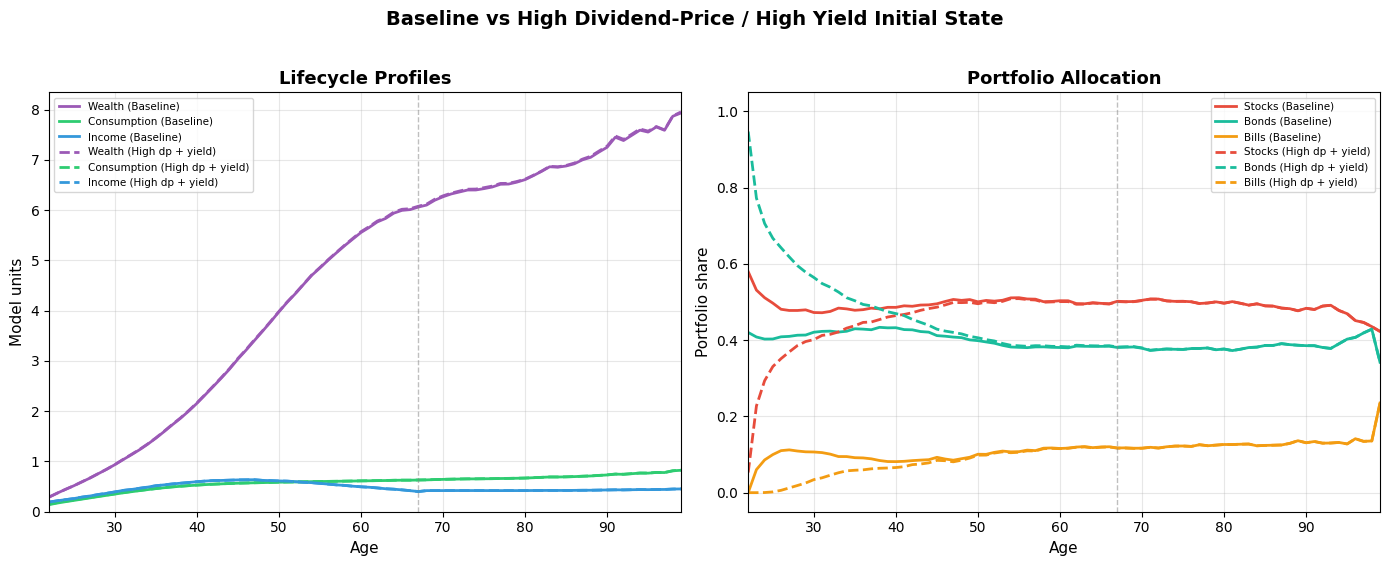

In [38]:
# Compare baseline vs high-dp/high-yield: lifecycle profiles and portfolio allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for sd, ls, tag in [(sim_data, '-', 'Baseline'), (sim_high, '--', 'High dp + yield')]:
    a = sd['alive']
    cs = cross_sectional_stats(sd['c'], a)
    ys = cross_sectional_stats(sd['income'], a)
    ws = cross_sectional_stats(sd['x'], a)

    axes[0].plot(ages, ws['mean'], color=COLORS['wealth'],      lw=2, ls=ls, label=f'Wealth ({tag})')
    axes[0].plot(ages, cs['mean'], color=COLORS['consumption'], lw=2, ls=ls, label=f'Consumption ({tag})')
    axes[0].plot(ages, ys['mean'], color=COLORS['income'],      lw=2, ls=ls, label=f'Income ({tag})')

for sd, ls, tag in [(sim_data, '-', 'Baseline'), (sim_high, '--', 'High dp + yield')]:
    a = sd['alive']
    ss = cross_sectional_stats(sd['alpha_s'], a)
    bs = cross_sectional_stats(sd['alpha_b'], a)
    bl = cross_sectional_stats(sd['alpha_bill'], a)

    axes[1].plot(ages, ss['mean'], color=COLORS['stocks'], lw=2, ls=ls, label=f'Stocks ({tag})')
    axes[1].plot(ages, bs['mean'], color=COLORS['bonds'],  lw=2, ls=ls, label=f'Bonds ({tag})')
    axes[1].plot(ages, bl['mean'], color=COLORS['bills'],  lw=2, ls=ls, label=f'Bills ({tag})')

for ax in axes:
    ax.axvline(model.retire_age, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Age', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ages[0], ages[-1])
    ax.legend(loc='best', fontsize=7.5)

axes[0].set_ylabel('Model units', fontsize=11)
axes[0].set_title('Lifecycle Profiles', fontsize=13, fontweight='bold')
axes[0].set_ylim(bottom=0)

axes[1].set_ylabel('Portfolio share', fontsize=11)
axes[1].set_title('Portfolio Allocation', fontsize=13, fontweight='bold')
axes[1].set_ylim(-0.05, 1.05)

fig.suptitle('Baseline vs High Dividend-Price / High Yield Initial State',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Investigation: Terminal Condition
Check the terminal consumption-to-wealth ratio from the policy function and diagnose whether the bequest motive is too strong.

In [ ]:
from math import exp as mexp

# ── Terminal consumption ratio from the policy function ──────────────────────
T = pc.n_age - 1  # terminal period index (age 99)
mid_z = pc.n_z // 2
mid_s = pc.N_state // 2

print("=" * 70)
print("TERMINAL CONDITION DIAGNOSTIC")
print("=" * 70)

# 1. Policy c/x ratio at terminal age across the wealth grid
c_terminal = C_mat[T, mid_z, mid_s, :]
ratio_cx = c_terminal / np.maximum(pc.wealth_grid, 1e-15)
print(f"\nTerminal c/x ratio at median (z, state):")
print(f"  min = {ratio_cx.min():.6f},  max = {ratio_cx.max():.6f}")
print(f"  At w=1:  c/x = {np.interp(1.0, pc.wealth_grid, ratio_cx):.6f}")
print(f"  At w=5:  c/x = {np.interp(5.0, pc.wealth_grid, ratio_cx):.6f}")
print(f"  At w=10: c/x = {np.interp(10.0, pc.wealth_grid, ratio_cx):.6f}")
print(f"  → Agent consumes {ratio_cx.mean()*100:.1f}% of wealth at terminal age")

# 2. Reproduce the terminal formula to check omega and ratio
A_mid = pc.annuity_factors[mid_s]
R_bill = mexp(pc.r_bill_grid[mid_s])
alpha_s_T = S_mat[T, mid_z, mid_s, pc.n_w // 2]
alpha_b_T = B_mat[T, mid_z, mid_s, pc.n_w // 2]

# Approximate E[R_port^(1-gamma)] at this state
from solver import build_gross_return_arrays
Rx_stock, Rx_bond = build_gross_return_arrays(pc.mu_r[mid_s, :, :], pc.ret_nodes)
alpha_bill = 1.0 - alpha_s_T - alpha_b_T
R_port_scenarios = alpha_s_T * R_bill * Rx_stock + alpha_b_T * R_bill * Rx_bond + alpha_bill * R_bill
Pi_row = pc.Pi_state[mid_s, :]
weights_2d = Pi_row[:, None] * pc.ret_weights[None, :]
moment = np.sum(weights_2d * R_port_scenarios ** (1.0 - model.gamma))
omega = model.b_bar * A_mid ** (model.gamma - 1.0) * moment
ratio_val = (model.beta * omega) ** (-1.0 / model.gamma)

print(f"\n── Bequest formula components ──")
print(f"  A(y_nom) = {A_mid:.4f}  (annuity factor at median state)")
print(f"  R_bill   = {R_bill:.6f}")
print(f"  alpha_s  = {alpha_s_T:.4f},  alpha_b = {alpha_b_T:.4f}")
print(f"  E[R_port^(1-gamma)] = {moment:.6f}")
print(f"  b_bar    = {model.b_bar}")
print(f"  omega    = b_bar * A^(gamma-1) * moment = {omega:.6f}")
print(f"  beta*omega = {model.beta * omega:.6f}")
print(f"  ratio    = (beta*omega)^(-1/gamma) = {ratio_val:.6f}")
print(f"  c/x      = ratio / (ratio + 1) = {ratio_val / (ratio_val + 1.0):.6f}")

# 3. Compare u'(c) vs b'(W) at median retirement wealth
w_med = np.median(sim_data['x'][sim_data['alive'][:, T], T]) if np.any(sim_data['alive'][:, T]) else 5.0
c_at_wmed = np.interp(w_med, pc.wealth_grid, c_terminal)
a_at_wmed = w_med - c_at_wmed
u_prime_c = c_at_wmed ** (-model.gamma)
# b'(W) = b_bar * (W/A)^(-gamma) / A
b_prime_W = model.b_bar * (a_at_wmed / A_mid) ** (-model.gamma) / A_mid

print(f"\n── Marginal utility comparison at median terminal wealth ──")
print(f"  Median terminal W = {w_med:.4f}")
print(f"  c(W) = {c_at_wmed:.4f},  savings = {a_at_wmed:.4f}")
print(f"  u'(c) = {u_prime_c:.4f}")
print(f"  b'(a) = {b_prime_W:.4f}  (before beta*R_port)")
print(f"  Ratio u'(c) / b'(a) = {u_prime_c / b_prime_W:.4f}")

# 4. c/x ratio across ALL ages at median state (shows drawdown pattern)
cx_by_age = np.zeros(pc.n_age)
for t in range(pc.n_age):
    c_t = C_mat[t, mid_z, mid_s, :]
    cx_t = c_t / np.maximum(pc.wealth_grid, 1e-15)
    # Evaluate at a representative wealth level
    cx_by_age[t] = np.interp(3.0, pc.wealth_grid, cx_t)

print(f"\n── Policy c/x ratio at W=3.0, median (z, state) ──")
for age in [22, 30, 40, 50, 60, 67, 70, 80, 90, 99]:
    t = age - model.start_age
    if 0 <= t < pc.n_age:
        print(f"  Age {age:3d}: c/x = {cx_by_age[t]:.4f}")
print("=" * 70)